## Introduction

Data centres are among the most infrastructure-intensive facilities in the modern economy. They require continuous, uninterrupted power supply, stable physical operating environments, and increasingly, access to low-carbon energy sources to meet corporate sustainability commitments. As demand for cloud computing, artificial intelligence, and digital services accelerates across Southeast Asia, both Singapore and Malaysia have emerged as leading candidates for data centre investment in the region. Singapore has long been the dominant hub, but land scarcity and a moratorium on new data centre construction imposed between 2019 and 2022 have pushed operators to consider Malaysia (particularly Johor) as an alternative or complementary location (Tay, 2022).

This project compares Singapore and Malaysia on four indicators relevant to data centre suitability, using publicly available data and a composite scoring approach. The four indicators were selected based on their relevance to three core operational requirements identified in the data centre siting literature:

**Climate risk** (mean temperature and precipitation) is included because ambient temperature directly affects cooling energy demand — one of the largest operating costs for any data centre — and precipitation levels serve as a proxy for flood exposure risk to physical infrastructure (Wahlroos et al., 2018). Higher temperatures require more energy-intensive cooling systems, while flood-prone environments increase the risk of physical damage and downtime.

**Grid stability** (electricity generation minus consumption surplus) reflects whether a location's power infrastructure can reliably support large additional electricity loads. Data centres are among the most power-intensive commercial facilities, and grid instability or supply deficits represent a direct operational risk (Avgerinou et al., 2017). A generation surplus indicates spare capacity in the grid to absorb new demand.

**Disaster resilience** (INFORM Global Risk Index score) captures the broader institutional and infrastructural capacity of a country to withstand and recover from crises, including natural hazards, conflict, and systemic shocks. Operational continuity is a non-negotiable requirement for data centre operators, and locations with higher disaster risk scores present greater long-term exposure to unplanned downtime (INFORM, 2025).

**Renewable energy share** \(percentage of electricity from renewable sources\) reflects the carbon credentials of the local grid. As hyperscalers and enterprise operators face growing pressure to meet net\-zero targets and match energy consumption with renewable supply, the green credentials of a host grid have become a material factor in siting decisions, and renewables are projected to meet nearly 50% of growth in data centre electricity demand by 2030 \(IEA, 2025\).

Each indicator is normalised to a 0–1 scale and averaged into a composite suitability score, with higher scores indicating greater suitability. The analysis is exploratory and comparative rather than prescriptive — the goal is to surface relative strengths and weaknesses across the two locations, not to produce a definitive ranking.

---

### References

Avgerinou, M., Bertoldi, P., & Castellazzi, L. (2017). Trends in data centre energy consumption under the European Code of Conduct for data centre energy efficiency. *Energies*, 10(10), 1470. https://doi.org/10.3390/en10101470

INFORM (2025). *INFORM Global Risk Index 2025*. European Commission Joint Research Centre. https://drmkc.jrc.ec.europa.eu/inform-index

International Energy Agency \(2025\). \*Energy and AI\*. IEA, Paris. [https://www.iea.org/reports/energy\-and\-ai](https://www.iea.org/reports/energy-and-ai) 

Tay, V. (2022). Singapore lifts moratorium on new data centres with green requirements. *The Straits Times*. 

Wahlroos, M., Pärssinen, M., Rinne, S., Syri, S., & Manner, J. (2018). Future views on waste heat utilization — case of data centres in northern Europe. *Renewable and Sustainable Energy Reviews*, 82, 1749–1764. https://doi.org/10.1016/j.rser.2017.10.058



In [5]:
#import
library(tidyverse)
library(ggplot2)

## 1. Climate (temperature and rainfall)

Temperature is one of the most cited selection criteria in literature because cooling accounts for roughly 30-0 of a data centres total energy consumption. Cooler climates lower coolign costs, while warmer regions increase energy expenses (https://www.ramboll.com/en-apac/insights/resilient-societies-and-liveability/data-centre-site-selection-criteria). This is reported consistently across both industry assessments and academic work.

We are looking for lower mean temperatures and lower humidity as indicators of data centre suitability.

Singapore Climate Data \(sg\_temp\_precip.csv\)

Source: National Environment Agency \(NEA\), Singapore, via data.gov.sg.

This dataset is published by Singapore's national meteorological authority and records monthly climate observations at the Changi Climate Station, Singapore's designated national climate reference station. Variables include mean, maximum, and minimum surface air temperature \(°C\), total rainfall \(mm\), and relative humidity \(%\). Data run from 1982 to the present and are updated monthly. For this project, mean temperature and total rainfall are extracted and aggregated to annual values.

This source is appropriate because it is the official, authoritative climate record for Singapore — the same data underpinning national environmental reporting. It is freely available, well\-maintained, and in a machine\-readable format. The Changi station is a nationally representative reference point for a city\-state of Singapore's size, making it a reasonable single\-location proxy for national climate conditions.

Malaysia Climate Data \(msia\_temp.csv, msia\_precip.csv\)

Source: World Bank Climate Change Knowledge Portal \(CCKP\), ERA5 0.25\-degree reanalysis dataset.

The CCKP aggregates and serves climate data from multiple modelling and observational sources for policy and research use. The Malaysia files use the ERA5 reanalysis product produced by the European Centre for Medium\-Range Weather Forecasts \(ECMWF\), which combines historical weather observations with atmospheric modelling to produce spatially consistent, gap\-free climate estimates. The temperature file contains annual mean surface air temperature \(°C\) and the precipitation file contains annual mean precipitation \(mm\), both aggregated to the national level, covering 1901–2024.

This source is appropriate for several reasons. First, Malaysia lacks a single equivalent to Singapore's Changi station that covers the whole country — ERA5 reanalysis provides national coverage that a single station record cannot. Second, the World Bank CCKP is a peer\-recognised platform widely used in environmental policy research, lending credibility to the data provenance. Third, the annual format and long time series allow direct alignment with Singapore's annual aggregates for the purposes of comparison.

A note on comparability: Both datasets are filtered to 1991–2024 for analysis to ensure a consistent time window. One limitation worth acknowledging is that Singapore's data derive from a single ground\-based station, while Malaysia's data are a nationally\-averaged reanalysis product — these are methodologically different measurement approaches. However, for the purpose of this project, which requires a single representative climate value per location to feed into a composite suitability score, both are fit for purpose and the limitation is noted.


In [6]:
#malaysia temperature data
msia_temp_raw <- read_csv("../raw-data/msia_temp.csv")

msia_temp <- msia_temp_raw %>%
    rename(year = Category,
          temp_c = 'Average Mean Surface Air Temperature (Annual Mean °C)') %>%
    select(year, temp_c) %>%
    filter(year >=1991, year <= 2024) %>%
    mutate(country = "Malaysia")

spec(msia_temp)

#malaysia precipitation data
msia_precip_raw <- read_csv("../raw-data/msia_precip.csv")

msia_precip <- msia_precip_raw %>%
  rename(year = Category,
         precip_mm = `Precipitation (Annual Mean mm)`) %>%
  select(year, precip_mm) %>%
  filter(year >= 1991, year <= 2024) %>%
  mutate(country = "Malaysia")

Rows: 124 Columns: 3


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (3): Category, Average Mean Surface Air Temperature (Annual Mean °C), 5-...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


NULL

Rows: 124 Columns: 3


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (3): Category, Precipitation (Annual Mean mm), 5-year smooth (Gaussian S...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [7]:
#singapore - reshaping climate data
sg_raw <- read_csv("../raw-data/sg_temp_precip.csv",
                   col_types = cols(.default = col_character()))

sg_long <- sg_raw %>%
  pivot_longer(cols = -DataSeries,
               names_to = "month_str",
               values_to = "value") %>%
  filter(value != "na") %>%
  mutate(value = as.numeric(value),
         year  = as.integer(str_extract(month_str, "\\d{4}"))) %>%
  filter(year >= 1991, year <= 2024)

unique(sg_long$DataSeries) 
#sg mean temp

sg_temp <- sg_long %>%
  filter(DataSeries %in% c("Air Temperature Means Daily Maximum",
                           "Air Temperature Means Daily Minimum")) %>%
  group_by(year) %>%
  summarise(temp_c = mean(value, na.rm = TRUE), .groups = "drop") %>%
  mutate(country = "Singapore")

#sg total rainfall
sg_precip <- sg_long %>%
  filter(str_detect(DataSeries, "Total Rainfall")) %>%
  group_by(year) %>%
  summarise(precip_mm = sum(value, na.rm = TRUE)) %>%
  mutate(country = "Singapore")

[1] "Air Temperature Means Daily Maximum"      
 [2] "Air Temperature Means Daily Minimum"      
 [3] "Air Temperature Absolute Extremes Maximum"
 [4] "Air Temperature Absolute Extremes Minimum"
 [5] "Total Rainfall"                           
 [6] "Highest Daily Rainfall Total"             
 [7] "Number Of Rainy Days"                     
 [8] "Bright Sunshine Daily Mean"               
 [9] "Minimum Relative Humidity"                
[10] "24 Hours Mean Relative Humidity"

In [8]:
#combine and run analysis
climate_temp   <- bind_rows(sg_temp, msia_temp)
climate_precip <- bind_rows(sg_precip, msia_precip)

climate <- left_join(climate_temp, climate_precip, by = c("year", "country"))

#summary(single value per country for composite score)
climate_summary <- climate %>%
  group_by(country) %>%
  summarise(mean_temp_c   = mean(temp_c,    na.rm = TRUE),
            mean_precip_mm = mean(precip_mm, na.rm = TRUE))

#print(sg_temp)
#print(sg_precip)
#unique(sg_long$DataSeries)
print(climate_summary)

# A tibble: 2 × 3
  country   mean_temp_c mean_precip_mm
  <chr>           <dbl>          <dbl>
1 Malaysia         26.4          3023.
2 Singapore        28.3          2155.


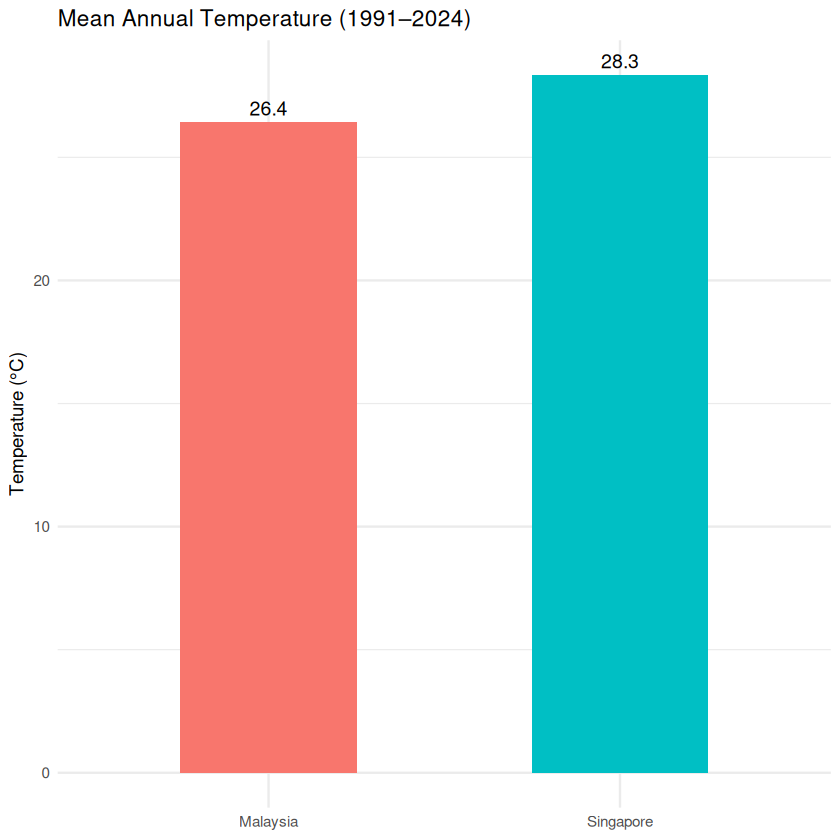

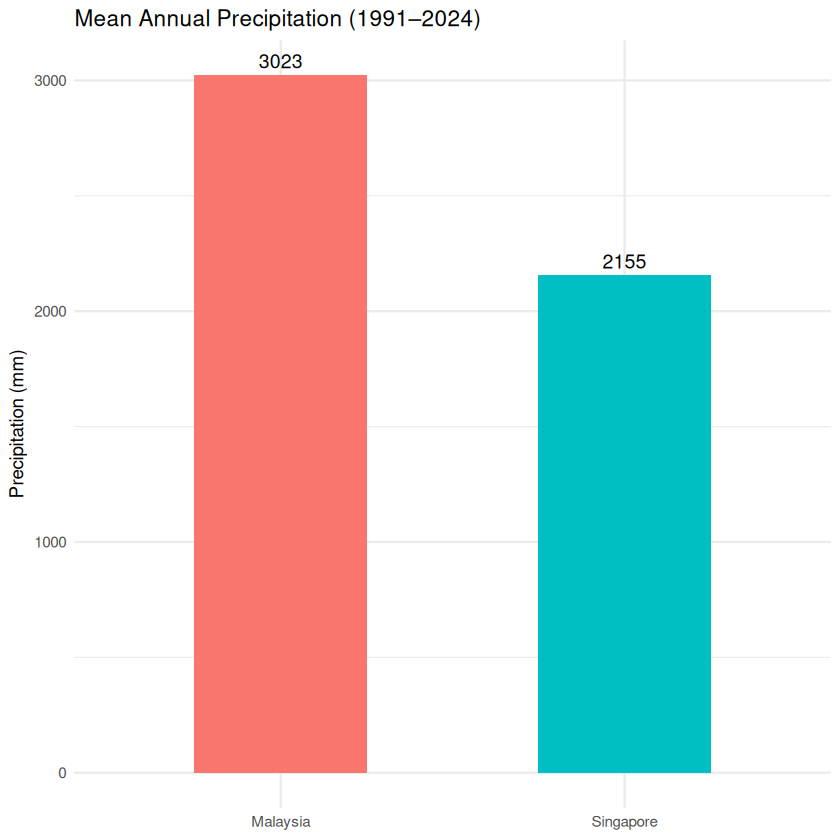

In [9]:

#temp bar chart
ggplot(climate_summary, aes(x = country, y = mean_temp_c, fill = country)) +
  geom_col(width = 0.5) +
  geom_text(aes(label = round(mean_temp_c, 1)), 
            vjust = -0.5, size = 4) +
  labs(title = "Mean Annual Temperature (1991–2024)",
       x = NULL, y = "Temperature (°C)") +
  theme_minimal() +
  theme(legend.position = "none")

#precip bar chart
ggplot(climate_summary, aes(x = country, y = mean_precip_mm, fill = country)) +
  geom_col(width = 0.5) +
  geom_text(aes(label = round(mean_precip_mm, 0)), 
            vjust = -0.5, size = 4) +
  labs(title = "Mean Annual Precipitation (1991–2024)",
       x = NULL, y = "Precipitation (mm)") +
  theme_minimal() +
  theme(legend.position = "none")


Temperature implications: Over the 1991–2024 period, Singapore recorded a higher mean annual temperature \(28.3°C\) than Malaysia \(26.0°C\), while Malaysia received substantially more precipitation on average \(3,023 mm/year\) compared to Singapore \(2,155 mm/year\). From a data centre suitability perspective, Singapore's higher ambient temperature implies greater cooling demand and therefore higher energy costs for thermal management. Malaysia's higher rainfall, while indicating greater flood exposure risk, also reflects a cooler baseline climate that is marginally more favourable for passive cooling. Both countries operate in a humid tropical climate that presents inherent challenges for data centre operations, and climate alone does not determine suitability — these indicators contribute to a broader composite score alongside grid stability, disaster resilience, and renewable energy share.


## 2. Electricity (Grid Stability)

Data descriptions
Singapore (sg_electricity.csv)
Source: Singapore Department of Statistics / Energy Market Authority, via data.gov.sg. Annual electricity generation and consumption figures in gigawatt-hours (GWh) from 1975 to 2024. The file is in wide format with years as columns. For this analysis, the top-level Electricity Generation and Electricity Consumption rows are used to compute an annual surplus or deficit (generation minus consumption), which serves as a proxy for grid stability. A positive surplus suggests the grid produces more than it consumes, indicating greater resilience for energy-intensive users like data centres.
Malaysia (msia_electricity_supply.csv, msia_electricity_consumption.csv)
Source: Department of Statistics Malaysia (DOSM), via open.dosm.gov.my. Monthly electricity supply and consumption in gigawatt-hours (GWh) from 2018 to mid-2024, broken down by sector (total, local, imports, etc.). For this analysis, only the total sector rows are used, aggregated to annual figures, and a surplus/deficit is computed the same way as Singapore.
A note on comparability: Singapore data is annual from 1975; Malaysia data is monthly from 2018 only. Both are filtered to 2018–2023 (the last complete year in Malaysia's dataset) to ensure a consistent comparison window.


In [10]:
#singapore electricity data
sg_elec_raw <- read_csv("../raw-data/sg_electricity.csv",
                        col_types = cols(.default = col_character()))

sg_elec <- sg_elec_raw %>%
  filter(DataSeries %in% c("Electricity Generation", "Electricity Consumption")) %>%
  pivot_longer(cols = -DataSeries,
               names_to = "year",
               values_to = "value") %>%
  mutate(year  = as.integer(year),
         value = as.numeric(value)) %>%
  filter(year >= 2018, year <= 2023) %>%
  filter(!is.na(value)) %>%
  pivot_wider(names_from = DataSeries, values_from = value) %>%
  rename(generation_gwh = `Electricity Generation`,
         consumption_gwh = `Electricity Consumption`) %>%
  mutate(surplus_gwh = generation_gwh - consumption_gwh,
         country = "Singapore")


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `value = as.numeric(value)`.
Caused by warning:
! NAs introduced by coercion”


In [11]:
#malaysia electricity 
msia_supply_raw      <- read_csv("../raw-data/msia_electricity_supply.csv")
msia_consumption_raw <- read_csv("../raw-data/msia_electricity_consumption.csv")

msia_supply <- msia_supply_raw %>%
  filter(sector == "total") %>%
  mutate(year = as.integer(format(as.Date(date), "%Y"))) %>%
  group_by(year) %>%
  summarise(generation_gwh = sum(supply, na.rm = TRUE), .groups = "drop")

msia_consumption <- msia_consumption_raw %>%
  filter(sector == "total") %>%
  mutate(year = as.integer(format(as.Date(date), "%Y"))) %>%
  group_by(year) %>%
  summarise(consumption_gwh = sum(consumption, na.rm = TRUE), .groups = "drop")

msia_elec <- left_join(msia_supply, msia_consumption, by = "year") %>%
  mutate(surplus_gwh = generation_gwh - consumption_gwh,
         country = "Malaysia") %>%
  filter(year >= 2018, year <= 2023)

Rows: 468 Columns: 3


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): sector
dbl  (1): supply
date (1): date



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 468 Columns: 3


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): sector
dbl  (1): consumption
date (1): date



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [12]:
#combine everything
elec <- bind_rows(sg_elec, msia_elec)

elec_summary <- elec %>%
  group_by(country) %>%
  summarise(mean_generation_gwh  = mean(generation_gwh,  na.rm = TRUE),
            mean_consumption_gwh = mean(consumption_gwh, na.rm = TRUE),
            mean_surplus_gwh     = mean(surplus_gwh,     na.rm = TRUE))

print(elec_summary)

# A tibble: 2 × 4
  country   mean_generation_gwh mean_consumption_gwh mean_surplus_gwh
  <chr>                   <dbl>                <dbl>            <dbl>
1 Malaysia              168715.              168715.          -0.0111
2 Singapore              55067.               52804.        2263.    


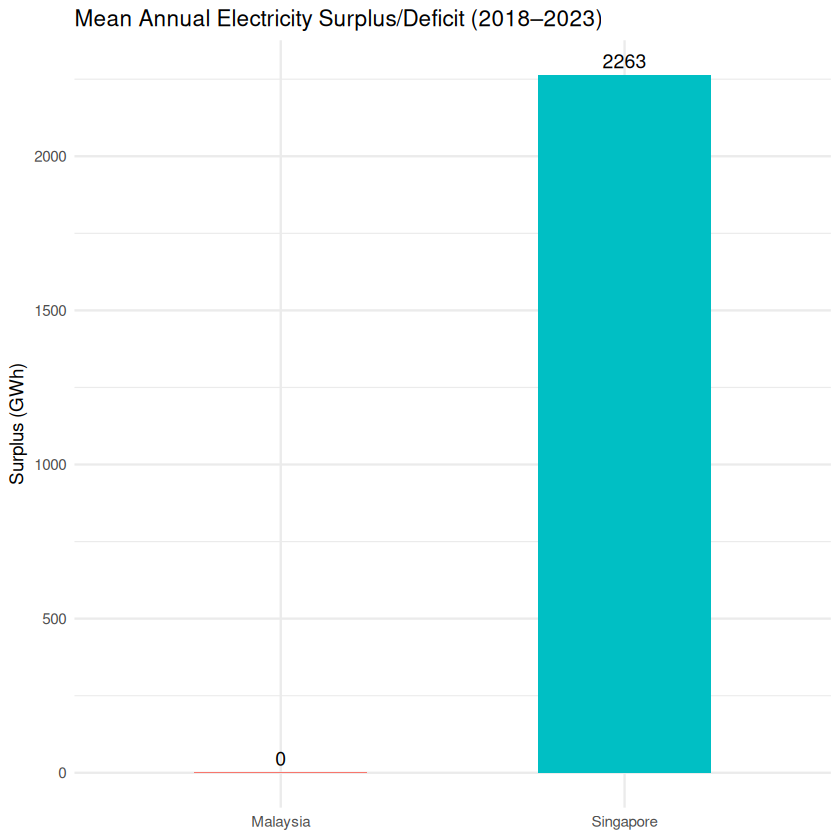

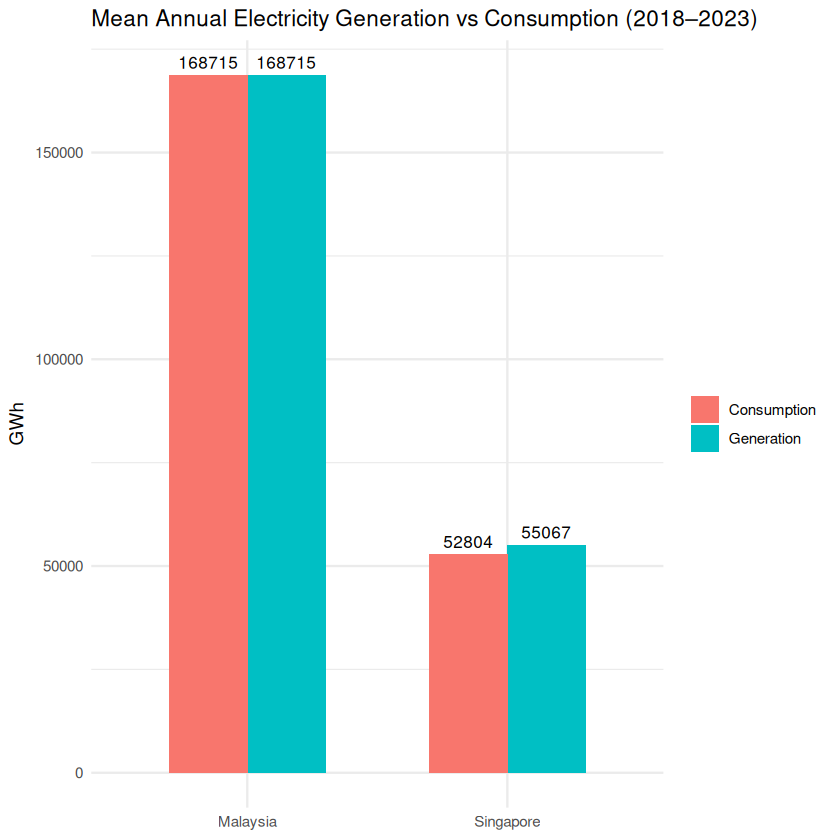

In [13]:
#plot bar chart for surplus and deficit
ggplot(elec_summary, aes(x = country, y = mean_surplus_gwh, fill = country)) +
  geom_col(width = 0.5) +
  geom_text(aes(label = round(mean_surplus_gwh, 0)),
            vjust = -0.5, size = 4) +
  labs(title = "Mean Annual Electricity Surplus/Deficit (2018–2023)",
       x = NULL, y = "Surplus (GWh)") +
  theme_minimal() +
  theme(legend.position = "none")

#grouped bar chart for generation vs consumption
elec_summary_long <- elec_summary %>%
  select(country, mean_generation_gwh, mean_consumption_gwh) %>%
  pivot_longer(cols = -country,
               names_to = "type",
               values_to = "gwh") %>%
  mutate(type = recode(type,
                       "mean_generation_gwh"  = "Generation",
                       "mean_consumption_gwh" = "Consumption"))

ggplot(elec_summary_long, aes(x = country, y = gwh, fill = type)) +
  geom_col(position = "dodge", width = 0.6) +
  geom_text(aes(label = round(gwh, 0)),
            position = position_dodge(width = 0.6),
            vjust = -0.5, size = 3.5) +
  labs(title = "Mean Annual Electricity Generation vs Consumption (2018–2023)",
       x = NULL, y = "GWh", fill = NULL) +
  theme_minimal()

Commentary: Over the period 2018–2023, Singapore maintained a consistent electricity surplus averaging 2,263 GWh per year, meaning it generated meaningfully more power than it consumed. Malaysia's generation and consumption were almost perfectly balanced, producing a near-zero surplus of just -0.01 GWh — effectively no buffer. From a data centre suitability perspective, Singapore's surplus is a positive signal: spare generation capacity suggests the grid can absorb additional large-scale demand, such as that from data centres, without straining supply. Malaysia's tight balance indicates less headroom, though it is worth noting Malaysia's absolute generation volume (168,715 GWh) is roughly three times Singapore's (55,067 GWh), reflecting its much larger land area and population — the surplus metric captures balance, not scale.

## 3. Disaster Resilience
The INFORM Global Risk Index is produced by the European Commission's Joint Research Centre in collaboration with the Inter-Agency Standing Committee. It assesses the risk of humanitarian crises and disasters for 191 countries using three dimensions: hazard and exposure (natural and human-made threats a country faces), vulnerability (socioeconomic conditions that make populations susceptible to harm), and lack of coping capacity (the ability of institutions and infrastructure to respond to and recover from crises). Each country receives a composite score from 0 to 10, where higher scores indicate greater disaster risk. 

For this project, the top-level composite INFORM Risk Index score is extracted for Singapore and Malaysia from the 2016–2025 trend dataset, and the mean score across this period is used as the disaster resilience indicator in the composite suitability score. In this case, a lower score indicates a more resilient environment, which is more suitable for data centre citing where operational continuity is critical.

In [14]:
#i could extract inform risk scores for sg and msia
#but simply taking the scores i need from the file and hardcoding them below

inform_summary <- tibble(
  country          = c("Singapore", "Malaysia"),
  mean_inform_score = c(0.68, 3.45)
)

print(inform_summary)

# A tibble: 2 × 2
  country   mean_inform_score
  <chr>                 <dbl>
1 Singapore              0.68
2 Malaysia               3.45


Note on the above: I downloaded the full 2016-2025 dataset from the DRMKC portal, but it was too large to upload to cocalc. Instead of doing that, I processed it externally by filtering for SGP and MYS for the top-level indicator, yielding 10 annual scores per country. 
I then calculated the mean scores for each country across 2016-2025 and hardcoded those summarised values. The full dtaset is available here: https://drmkc.jrc.ec.europa.eu/inform-index/INFORM-Risk/Results-and-data


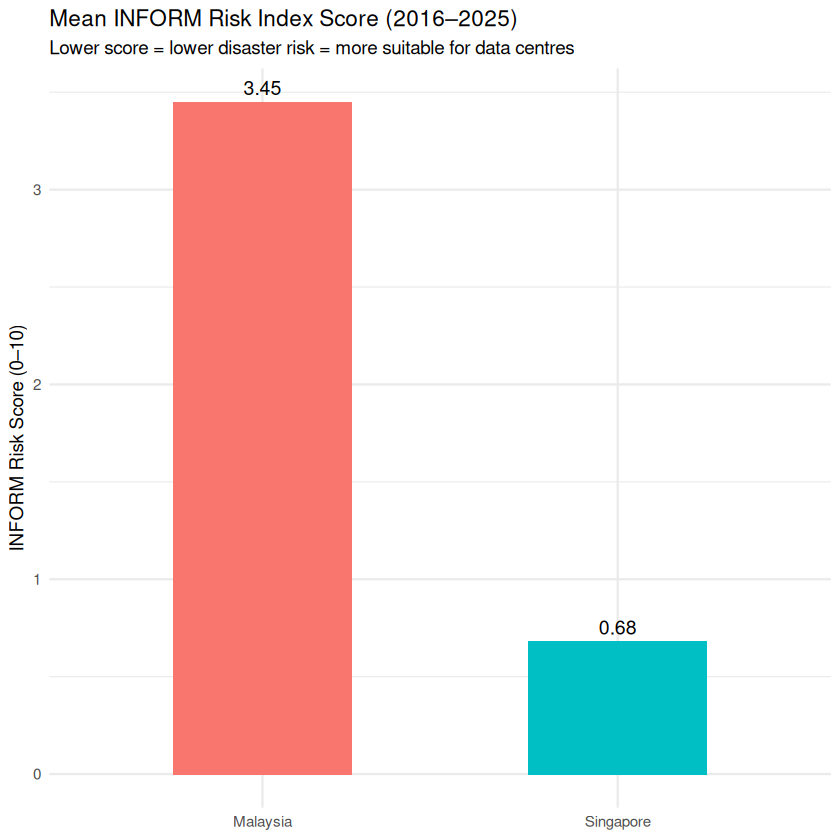

In [15]:
#plot

ggplot(inform_summary, aes(x = country, y = mean_inform_score, fill = country)) +
  geom_col(width = 0.5) +
  geom_text(aes(label = round(mean_inform_score, 2)),
            vjust = -0.5, size = 4) +
  labs(title = "Mean INFORM Risk Index Score (2016–2025)",
       subtitle = "Lower score = lower disaster risk = more suitable for data centres",
       x = NULL,
       y = "INFORM Risk Score (0–10)") +
  theme_minimal() +
  theme(legend.position = "none")

Commentary on disaster risk: Singapore's mean INFORM Risk Index score of 0.68 over 2016–2025 places it among the lowest-risk countries globally, reflecting its minimal exposure to natural hazards, absence of significant conflict risk, and highly developed institutional and infrastructure capacity. Malaysia's mean score of 3.45 indicates moderate risk, driven by greater exposure to flood events, tropical weather, and comparatively higher vulnerability scores. For data centre suitability, this indicator carries significant weight — unplanned downtime caused by disasters or infrastructure failure represents a critical operational and financial risk. On this dimension, Singapore holds a clear and substantial advantage over Malaysia, with a risk score roughly five times lower. This gap is unlikely to narrow significantly in the near term given the structural nature of the underlying drivers.

## 4. Renewable energy share

The Our World in Data (OWID) Energy Dataset is a comprehensive open-access compilation of global energy metrics maintained by Our World in Data, drawing on underlying data from Ember's Yearly Electricity Data and the Energy Institute's Statistical Review of World Energy. It covers over 200 countries with annual observations on energy consumption, electricity generation by source, and emissions metrics. The dataset is structured as one row per country per year and is updated regularly. For this project, the renewables_share_elec column is extracted for Singapore and Malaysia — this represents renewables as a percentage of total electricity generation, encompassing hydropower, solar, wind, bioenergy, and geothermal. Years 2015–2023 are used to align with the most complete and consistent period available for both countries. Source: github.com/owid/energy-data

In [16]:
#renewable energy share

owid_raw <- read_csv("../raw-data/owid-energy-data.csv")

renewables <- owid_raw %>%
  
  #keep sg and msia
  filter(iso_code %in% c("SGP", "MYS")) %>%
  
  #drop variables that arent needed
  select(country, year, renewables_share_elec) %>%
  
  #time filter and remove missing values
  filter(year >= 2015, year <= 2023) %>%
  filter(!is.na(renewables_share_elec))

#summary value for each country composite score
renewables_summary <- renewables %>%
  group_by(country) %>%
  summarise(mean_renewables_pct = mean(renewables_share_elec, na.rm = TRUE))

print(renewables_summary)

Rows: 23232 Columns: 130


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): country, iso_code
dbl (128): year, population, gdp, biofuel_cons_change_pct, biofuel_cons_chan...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 2 × 2
  country   mean_renewables_pct
  <chr>                   <dbl>
1 Malaysia                16.6 
2 Singapore                3.18


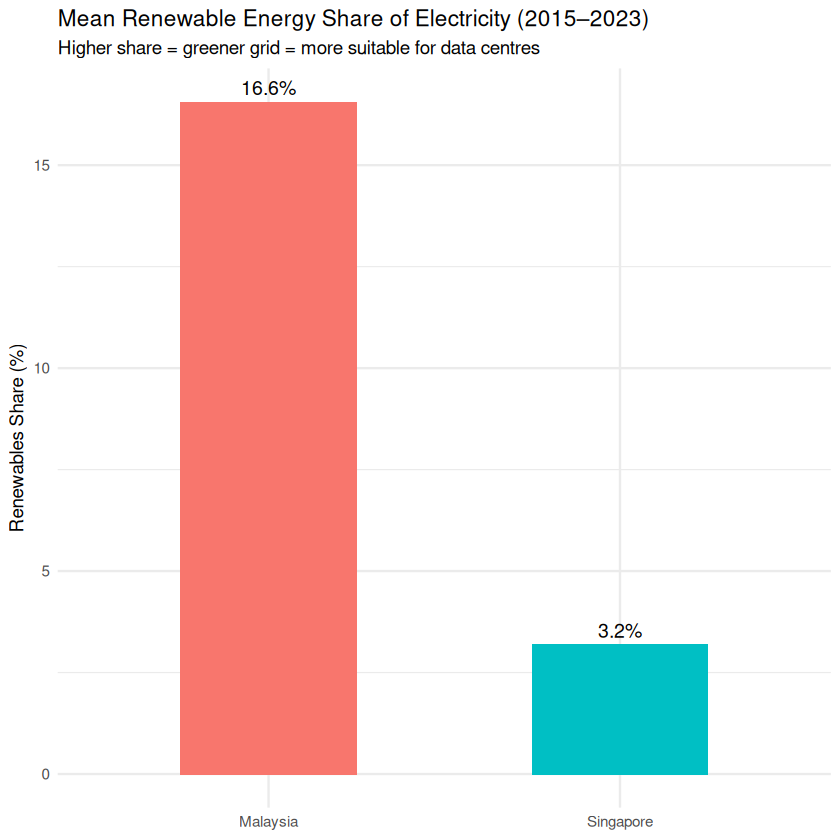

In [17]:
#plot renewable energy share
ggplot(renewables_summary, aes(x = country, y = mean_renewables_pct, fill = country)) +
  geom_col(width = 0.5) +
  geom_text(aes(label = paste0(round(mean_renewables_pct, 1), "%")),
            vjust = -0.5, size = 4) +
  labs(title = "Mean Renewable Energy Share of Electricity (2015–2023)",
       subtitle = "Higher share = greener grid = more suitable for data centres",
       x = NULL, y = "Renewables Share (%)") +
  theme_minimal() +
  theme(legend.position = "none")

Over 2015–2023, Malaysia averaged 16.6% renewable electricity, driven primarily by hydropower which forms the backbone of its renewable generation, with growing contributions from solar and biomass in recent years. Singapore averaged just 3.18% over the same period, reflecting its structural constraints as a small, densely built island state with limited land for solar deployment, no viable hydropower, and negligible wind resources. Its grid remains dominated by natural gas at around 92–95% of generation. On this indicator Malaysia holds a clear advantage. However, it is worth noting that neither country's grid would be considered particularly green by global standards — the global average renewable share sits well above both. For data centre operators with net-zero commitments, this represents a shared challenge for both locations, though Malaysia's higher renewable base and continued hydropower capacity give it a meaningfully better starting position.

## Normalisation of the four indicators
This section assembles the composite suitability score. Each of the four indicators is measured on a different scale and unit, so they cannot be averaged directly. We first apply min-max normalisation to rescale each indicator to a 0–1 range. Indicators where a higher raw value is *worse* for data centre suitability (temperature, precipitation, and INFORM risk score) are inverted before normalisation so that a score of 1 always means "most suitable" and 0 always means "least suitable." The four normalised scores are then averaged to produce a single composite suitability score per country.

Note: with only two countries, min-max normalisation maps one country to 0 and the other to 1 on each indicator. The composite score therefore reflects the *relative* advantage across indicators, not an absolute measure of suitability.

In [18]:
#combine all four indicator summary values into one data frame
composite <- tibble(
  country        = c("Singapore", "Malaysia"),
  mean_temp_c    = c(28.3, 26.0),      # higher = worse (more cooling demand)
  mean_precip_mm = c(2155, 3023),      # higher = worse (more flood risk)
  mean_surplus_gwh   = c(2263, -0.01), # higher = better (more grid headroom)
  mean_inform_score  = c(0.68, 3.45),  # higher = worse (more disaster risk)
  mean_renewables_pct = c(3.18, 16.6)  # higher = better (greener grid)
)

#min-max normalisation function
#invert where higher raw value = worse suitability
minmax_norm <- function(x, invert = FALSE) {
  normed <- (x - min(x)) / (max(x) - min(x))
  if (invert) normed <- 1 - normed
  return(normed)
}

#normalise
#invert: temp, precip, INFORM score (higher raw = worse)
#not inverted: grid surplus, renewables share (higher raw = better)
composite_norm <- composite %>%
  mutate(
    score_temp      = minmax_norm(mean_temp_c,         invert = TRUE),
    score_precip    = minmax_norm(mean_precip_mm,      invert = TRUE),
    score_surplus   = minmax_norm(mean_surplus_gwh,    invert = FALSE),
    score_inform    = minmax_norm(mean_inform_score,   invert = TRUE),
    score_renewables = minmax_norm(mean_renewables_pct, invert = FALSE)
  )

#composite score (simple avg)
composite_norm <- composite_norm %>%
  mutate(
    composite_score = rowMeans(select(., starts_with("score_")))
  )

#print
composite_norm %>%
  select(country, starts_with("score_"), composite_score)

country,score_temp,score_precip,score_surplus,score_inform,score_renewables,composite_score
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Singapore,0,1,1,1,0,0.6
Malaysia,1,0,0,0,1,0.4


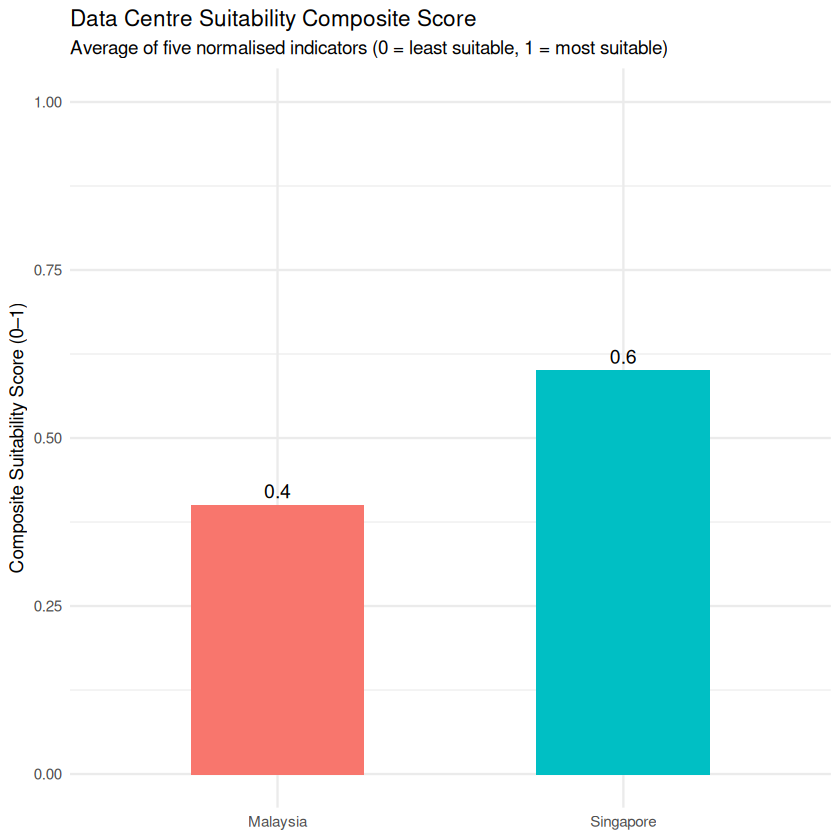

In [19]:
#composite suitability score bar chart
ggplot(composite_norm, aes(x = country, y = composite_score, fill = country)) +
  geom_col(width = 0.5) +
  geom_text(aes(label = round(composite_score, 2)),
            vjust = -0.5, size = 4) +
  scale_y_continuous(limits = c(0, 1)) +
  labs(title = "Data Centre Suitability Composite Score",
       subtitle = "Average of five normalised indicators (0 = least suitable, 1 = most suitable)",
       x = NULL, y = "Composite Suitability Score (0–1)") +
  theme_minimal() +
  theme(legend.position = "none")

## Interpretation

Across the five normalised indicators, Singapore scores 0.6 and Malaysia 0.4, suggesting Singapore holds a moderate overall advantage as a data centre location based on the dimensions examined. Singapore's lead is driven primarily by its exceptional disaster resilience — scoring near-perfect on the INFORM indicator — and its consistent electricity surplus, both of which are critical operational requirements for data centres. Malaysia scores better on renewable energy share and climate conditions, with a lower ambient temperature and a meaningfully greener grid, both increasingly important factors as the industry faces pressure to reduce its environmental footprint.
The result is not a clear-cut verdict in favour of either country. Singapore's structural advantages in institutional stability, grid reliability, and disaster resilience are well-established and unlikely to change in the near term. Malaysia's advantages in renewable energy and climate are real but arguably less decisive for day-to-day data centre operations. A data centre operator prioritising uptime and risk management would favour Singapore; one prioritising sustainability credentials and lower cooling costs might look more favourably at Malaysia.
These findings should be interpreted with caution given the limitations of the analysis: only two countries are compared, national-level data masks significant subnational variation within Malaysia, and the equal weighting of all five indicators does not reflect the fact that some dimensions, particularly disaster resilience and grid stability, may carry more practical weight for data centre siting decisions than others.

## Limitations and Further study
The most significant limitation of this analysis is its use of national-level data throughout. Malaysia in particular is a geographically and infrastructurally diverse country — Kuala Lumpur, Johor, and Penang have meaningfully different grid infrastructure, disaster exposure profiles, and renewable energy access compared to the national average. Treating Malaysia as a single unit obscures this variation and likely understates the suitability of its most developed urban corridors. A more rigorous analysis would operate at the state or city level, comparing specific locations such as Singapore against Kuala Lumpur, Johor Bahru, or Penang directly.

A second limitation is equal weighting of all five indicators in the composite score. In practice, disaster resilience and grid stability tend to be the most operationally critical factors for data centre siting — a facility that scores well on renewable energy but experiences frequent outages or flood events is not a viable location. Future work could apply weighted scoring informed by industry standards or expert elicitation.

Third, several potentially relevant indicators were excluded due to data availability constraints, including carbon intensity of the grid, land and water costs, latency to major internet exchange points, and regulatory environment for foreign data centre operators. Incorporating these would produce a more complete picture.

Finally, the analysis reflects a snapshot of conditions over recent historical periods. Both countries are actively investing in renewable energy capacity and grid infrastructure, meaning relative positions on several indicators may shift materially within the next decade.